In [1]:
import ROOT as r 
import fedrarootlogon
import numpy as np 
%jsroot off

Welcome to JupyROOT 6.26/06
Load FEDRA libs


In [2]:
OutputFileVtx = r.TFile("output_v2_b333.root", "READ")
tracks = OutputFileVtx.Get("tracks")

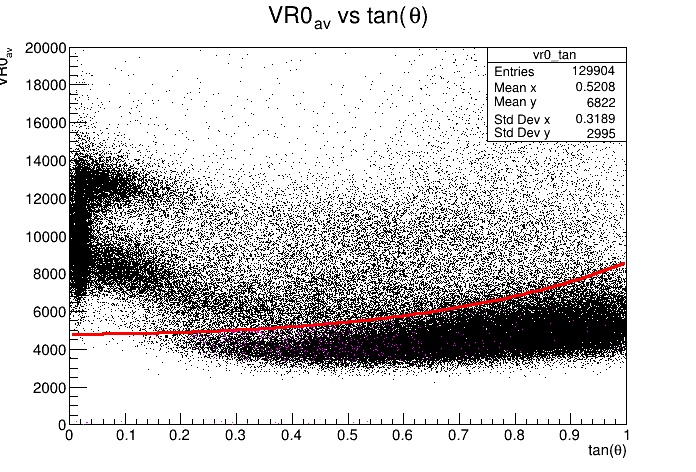

In [3]:
c = r.TCanvas()
tracks.Draw("VR0_av:s[0].Theta()>>vr0_tan(100, 0,1, 100, 0, 20000)", "k0>0", "")

k0_min = 3
brick_id = "GSI3"
c = r.TCanvas()
vr0_tan = r.gDirectory.Get("vr0_tan")
vr0_tan.SetTitle("VR0_{av} vs tan(#theta); tan(#theta); VR0_{av}")
vr0_tan.Draw("")
c.Draw()
r.gPad.Update()
st = vr0_tan.FindObject("stats")
st.SetX1NDC(0.70)
st.SetX2NDC(0.90)
st.SetY1NDC(0.70)
st.SetY2NDC(0.90)
t1 = r.TText(c.GetUxmax()/15, 2000, brick_id)
t1.SetTextColor(1)
t1.SetTextSize(20)
t1.Draw("SAME")

a2, b2 = 2400, 0.95  #2400, 0.95 x k0>=4
c2, d2 = 100, .45

cut_curve2 = r.TF1("cut_bk", str(a2)+"*(1 + exp("+str(b2)+ " *x*x))", 0, 1)
cut_curve2.SetLineColor(2)
cut_curve2.SetLineWidth(3)
cut_curve2.Draw("SAME")

c2 = r.TCanvas()
tracks.Draw("VR0_av:s[0].Theta()>>vr0_tan2(100, 0,1, 100, 0, 20000)", "Z==-2 && in_vtx==1", "")
vr0_tan2 = r.gDirectory.Get("vr0_tan2")
vr0_tan2.SetTitle("VR0_{av} vs tan(#theta); tan(#theta); VR0_{av}")
c.cd()
vr0_tan2.SetMarkerSize(2)
vr0_tan2.SetMarkerColor(r.kMagenta)
vr0_tan2.Draw("SAME")



c.Draw()

In [4]:
vtxFile = r.TFile("vertices_improved_fast_3NEW.root", "READ")
vtx = vtxFile.Get("vtx")

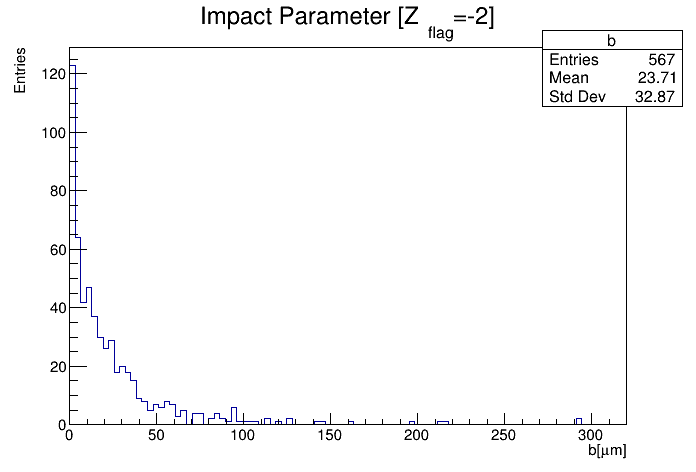

In [5]:
c = r.TCanvas()
vtx.Draw("impactparameter>>b", "Z_flag2==-2 && npl+plate>31")

hb = r.gDirectory.Get("b")
hb.SetTitle("Impact Parameter [Z_{flag}=-2]; b[#mum];Entries")
hb.Draw()

c.Draw()

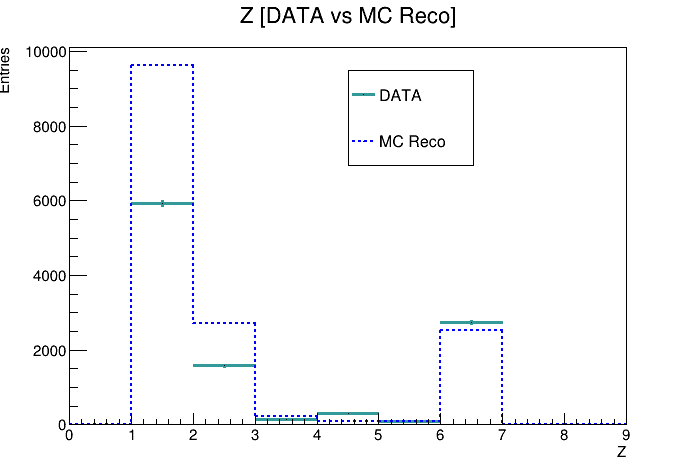

In [6]:
vtx.Draw("TMath::Max(Z_flag2,1)>>h_data(9, 0, 9)", "npl+plate>31")
h_data = r.gDirectory.Get("h_data")
h_data.SetLineColor(r.kCyan-2)
h_data.SetFillColor(0)
h_data.SetLineWidth(3)
h_data.Sumw2(r.kFALSE)
h_data.Scale(1)
#h_data.SetLineStyle(2)
#h_data.Write()
h_data.Draw("P")

mc_file = r.TFile("vertices_improved_fast_3NEW_MCr.root", "READ")
mc_vtx = mc_file.Get("vtx")

mc_vtx.Draw("TMath::Min(TMath::Max(Z_flag2,1), 6)>>h_mc(9, 0, 9)", "npl+plate>31")
h_mc = r.gDirectory.Get("h_mc")
h_mc.SetLineColor(r.kBlue)
h_mc.Sumw2(r.kFALSE)
h_mc.SetLineWidth(2)
h_mc.SetLineStyle(2)

#h_mc.Scale(100./h_mc.GetEntries())

hsz = r.THStack("hsz", "Charge Comparison Vtx Tracks")
hsz.SetTitle("Z [DATA vs MC Reco];Z;Entries")
hsz.Add(h_data)
hsz.Add(h_mc)

#hsz.Write()

legend = r.TLegend(0.5,0.65,0.68,0.85)
legend.AddEntry(h_data, "DATA")
legend.AddEntry(h_mc, "MC Reco")
#legend.Write("leg")

c = r.TCanvas()
hsz.Draw("nostack")
legend.Draw("same")
c.Draw()

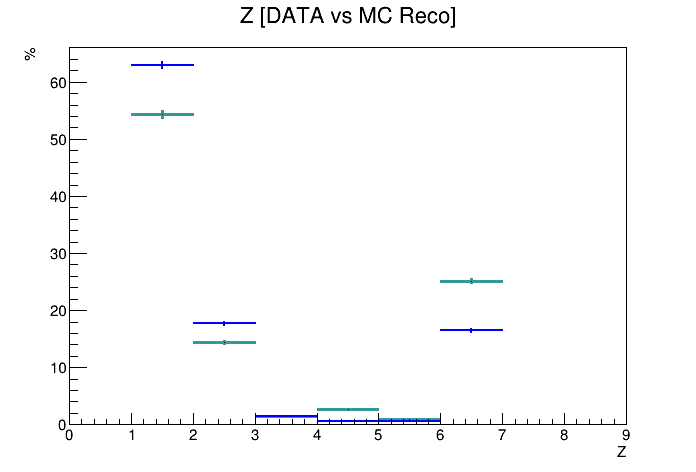

In [7]:
hsz2 = r.THStack("hsz2", "Charge Comparison Vtx Tracks")
hsz2.SetTitle("Z [DATA vs MC Reco];Z; %")

h_data.Scale(100./h_data.GetEntries())
h_mc.Scale(100./h_mc.GetEntries())
h_mc.SetLineStyle(1)
hsz2.Add(h_data)
hsz2.Add(h_mc)

c = r.TCanvas()
hsz2.Draw("pfcnostack")
c.Draw()